# Evergreen Python 백테스트 노트북

이 노트북은 Python 백테스트의 README이자 스모크 테스트다. 기본 실행은 v1부터 v5까지 모든 전략을 공식 Upbit SDK 일봉 데이터로 비교한다.

실제 Upbit 일봉 데이터는 `outputs/data/upbit-cache`에 CSV로 캐시된다. 최초 실행은 공개 캔들 API를 호출하고, 같은 기간/마켓은 다음부터 캐시를 먼저 읽는다.

현재 공식 SDK는 캔들/주문/계좌 같은 OpenAPI 리소스를 제공하고, RSI/EMA/ATR 같은 전략 지표 계산기는 제공하지 않는다. 그래서 데이터 조회는 SDK를 쓰고, 지표 계산은 버전별 전략 코드와 Java 전략 엔진에서 같은 계약으로 유지한다.


## 전략 설명서

### 공통 연동정의

모든 전략은 같은 입력과 출력 계약을 따른다.

- 입력: `CandleBar[]`, `signal_index`, 현재 포지션(`qty`, `avgPrice`, `updatedAt`, `positionRatio`), 버전별 파라미터 JSON
- 출력: `StrategyEvaluation`
- 실행 판단: `decision.action`은 `BUY`, `SELL`, `HOLD` 중 하나
- 주문 비중: `decision.targetPositionRatio`는 `evergreen.trading.signal-order-notional` 기준 목표 포지션 비중이다. 0.0은 전량 현금, 1.0은 기준 금액만큼 보유다. v3처럼 변동성 비중 전략은 `max_leverage`까지 값을 낼 수 있으며, LIVE 현물 주문은 실제 가용 KRW 안에서만 증액한다.
- 판단 이유: `decision.signalReason`은 매수/매도/유지의 원인을 기록한다.
- 진단값: `diagnostics`는 전략별 보조 지표다. 실행 판단의 필수 계약이 아니라 로그, 차트, 디버깅용이다.

Java에서는 v1~v5가 모두 `TradingStrategyEngine`으로 등록되고, Python 계약 파일도 같은 `StrategyInput -> StrategyEvaluation` 구조를 내보낸다. 전략별 설정은 JSON/설정값으로 넣고, 출력은 항상 `action`, `signalReason`, `targetPositionRatio`, `diagnostics`로 읽으면 된다.

Java 주문 계층은 `targetPositionRatio`를 목표 포지션 비중으로 받아 처리한다. 현재 비중은 보유 수량과 신호 캔들 종가를 `signal-order-notional` 기준 금액과 비교해 계산한다. 0.0은 전량 매도, 1.0은 기준 금액만큼 매수이며, 중간 비중은 보유 수량을 비례 매도하거나 증액 매수 금액을 조정한다. LIVE 모드의 증액 매수는 실제 가용 KRW를 넘지 않는다.

### v1: MA + RSI

가장 단순한 추세 추종 베이스라인이다. 가격이 이동평균 위에 있고 이동평균 기울기가 상승이며 RSI가 설정값보다 낮을 때 매수하고, 가격이 이동평균 아래로 내려가면 매도한다. 포지션은 0 또는 1의 전량 진입/전량 청산이다. 주요 조정값은 `rsi_buy`, `ma_len`, `ma_slope_days`다.

### v2: Regime + ATR Stop

EMA 밴드로 상승/하락 국면을 나누고 ATR 추적 손절을 붙인 전략이다. `BEAR`에서 `BULL`로 전환될 때 매수하고, `BULL`에서 `BEAR`로 전환되거나 ATR 추적 손절이 발생하면 매도한다. 주요 조정값은 `regime_ema_len`, `atr_period`, `atr_trail_multiplier`, `regime_band`다.

### v3: Volatility Target + Regime

v2 구조에 변동성 기반 목표 비중 조절을 추가한 전략이다. 상승 국면에서 목표 변동성에 맞춰 현재 비중보다 목표 비중이 커지면 증액하고, 하락 국면이나 ATR 추적 손절 또는 목표 비중 축소가 필요하면 감액한다. 포지션은 0.0부터 `max_leverage`까지의 동적 목표 비중이다. 주요 조정값은 `vol_target`, `max_leverage`, `min_exposure`와 레짐/ATR 파라미터다.

### v4: Weekly Filter

v2에 주간 EMA 필터를 추가한 전략이다. 일봉 레짐이 매수 신호를 내고 주간 필터도 상승으로 판단할 때만 진입한다. 매도는 일봉 레짐 매도 또는 ATR 추적 손절 기준을 따른다. 주요 조정값은 `weekly_ema_len`과 v2 계열 파라미터다.

### v5: Adaptive ATR Exit

v2의 ATR 추적 손절을 변동성 국면에 따라 다르게 적용하는 전략이다. `BEAR`에서 `BULL`로 전환될 때 매수하고, `BULL`에서 `BEAR`로 전환되거나 현재 변동성 국면에 맞춘 ATR 추적 손절이 발생하면 매도한다. 주요 조정값은 `atr_mult_low_vol`, `atr_mult_high_vol`, `vol_regime_lookback`, `vol_regime_threshold`, `regime_band`다.

### 선택 기준

- 단순 기준선이 필요하면 v1
- 안정적인 레짐/손절 베이스라인이 필요하면 v2
- 비중 조절까지 실험하려면 v3
- 큰 추세 필터를 강하게 걸고 싶으면 v4
- 변동성 국면별 손절을 보고 싶으면 v5


## 1. 프로젝트 경로와 커널 확인

IntelliJ나 Jupyter를 어디서 열어도 import가 되도록 프로젝트 루트를 찾고 `PYTHONPATH`에 추가한다. IntelliJ에서는 프로젝트 인터프리터를 `.venv`로 선택하고 커널은 `Python 3`를 쓰면 된다. 다른 위치에서 실행해야 하면 환경 변수 `EVERGREEN_PROJECT_ROOT`에 프로젝트 루트를 넣으면 된다.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def 프로젝트_루트_찾기() -> Path:
    env_root = os.environ.get("EVERGREEN_PROJECT_ROOT")
    if env_root:
        return Path(env_root).expanduser().resolve()

    candidates = [Path.cwd(), *Path.cwd().parents, Path("/Users/moon/IdeaProjects/evergreen")]
    for candidate in candidates:
        if (candidate / "settings.gradle").exists() and (candidate / "evergreen_backtest/models/v5.py").exists():
            return candidate.resolve()
    raise RuntimeError("Evergreen 프로젝트 루트를 찾지 못했다. EVERGREEN_PROJECT_ROOT를 설정해라.")


PROJECT_ROOT = 프로젝트_루트_찾기()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "outputs" / ".matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(PROJECT_ROOT / "outputs" / ".cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

for candidate in (PROJECT_ROOT,):
    text = str(candidate)
    if text not in sys.path:
        sys.path.insert(0, text)

print("프로젝트 루트:", PROJECT_ROOT)
print("Python:", sys.executable)

프로젝트 루트: /Users/moon/IdeaProjects/evergreen
Python: /Users/moon/IdeaProjects/evergreen/.venv/bin/python3


## 2. 실행 API 불러오기

전략 모델은 `evergreen_backtest/models/v*.py`에서 자동으로 찾고, 실행은 `evergreen_backtest` 패키지가 담당한다.

In [2]:
from datetime import datetime, timezone
from pprint import pprint
import importlib
import sys
import pandas as pd

# 개발 중 리팩터링된 패키지를 노트북 커널 재시작 없이 다시 읽기 위한 초기화다.
for 모듈명 in list(sys.modules):
    if 모듈명 == "evergreen_backtest" or 모듈명.startswith("evergreen_backtest."):
        del sys.modules[모듈명]
importlib.invalidate_caches()

from evergreen_backtest.runner import BacktestRunRequest, run_backtest
from evergreen_backtest.versions import available_versions
from evergreen_backtest.walk_forward import WalkForwardConfig
from evergreen_backtest.plotting import plot_walk_forward_equity

print("사용 가능한 전략 버전:", ", ".join(available_versions()))


사용 가능한 전략 버전: v1, v2, v3, v4, v5


## 3. 여기만 바꿔서 실행

- `실행할_버전`: 기본값 `("all",)`은 v1~v5 전체 실행이다. 특정 버전만 보려면 `("v5",)`처럼 넣는다.
- `공통_설정`: 모든 모델에 적용한다. 각 모델이 모르는 항목은 자동으로 무시된다.
- `버전별_설정`: 특정 모델에만 적용한다. 오타나 지원하지 않는 항목은 바로 에러를 낸다.
- `워크포워드_범위_후보`: 시계열 시작점, 학습 구간, 다음 검증 구간을 바꿔가며 버전별 하이퍼파라미터 적합도를 비교한다.


In [3]:
실행할_버전 = ("all",)
마켓 = "KRW-BTC"
시작일 = datetime(2020, 1, 1, tzinfo=timezone.utc)
종료일 = None

# 공통 설정은 모든 모델에 적용된다. 모델이 모르는 항목은 자동으로 무시된다.
공통_설정 = {
    "top_k": 5,
    "grid_parallelism": 1,
}

# 범위는 "시작:끝:간격"이다. 예: "10:20:5" -> 10, 15, 20
버전별_설정 = {
    "v1": {
        "grid_rsi_range": "20:45:5",
        "grid_ma_len_range": "20:120:10",
        "grid_ma_slope_range": "1:9:2",
    },
    "v2": {
        "grid_ma_len_range": "160:240:20",
        "grid_atr_period_range": "10:20:2",
        "grid_atr_trail_mult_range": "2:4:1",
        "grid_regime_band_range": "0.01:0.04:0.01",
    },
    "v3": {
        "grid_vol_target_range": "0.01:0.04:0.01",
        "grid_max_leverage_range": "1:3:0.5",
        "grid_min_exposure_range": "0:0.5:0.25",
    },
    "v4": {
        "grid_weekly_ema_len_range": "10:40:10",
    },
    "v5": {
        "grid_atr_mult_low_vol_range": "2:3:0.5",
        "grid_atr_mult_high_vol_range": "4:6:1",
        "grid_vol_regime_threshold_range": "0.6:0.9:0.1",
    },
}

워크포워드_범위_후보 = {
    "full_3y_train_6m_test": {
        "from_dt": datetime(2020, 1, 1, tzinfo=timezone.utc),
        "to_dt": 종료일,
        "config": WalkForwardConfig(enabled=True, train_window_days=1095, test_window_days=180, min_train_bars=365),
    },
    "recent_2y_train_3m_test": {
        "from_dt": datetime(2021, 1, 1, tzinfo=timezone.utc),
        "to_dt": 종료일,
        "config": WalkForwardConfig(enabled=True, train_window_days=730, test_window_days=90, min_train_bars=365),
    },
    "long_4y_train_6m_test": {
        "from_dt": datetime(2020, 1, 1, tzinfo=timezone.utc),
        "to_dt": 종료일,
        "config": WalkForwardConfig(enabled=True, train_window_days=1460, test_window_days=180, min_train_bars=365),
    },
}


## 4. 백테스트 실행

이 셀이 노트북의 테스트 역할을 한다. 기본값에서는 v1~v5 전체 결과가 모두 나와야 한다.


### 워크포워드가 하는 일

워크포워드는 과거 전체를 한 번에 보고 가장 좋아 보이는 전략을 고르는 방식이 아니라, 시계열을 여러 학습/검증 구간으로 쪼개서 반복 검증한다.

1. 버전 로직(v1~v5)을 먼저 고정한다.
2. 그 버전의 하이퍼파라미터 후보를 `train_window_days`만큼의 과거 구간에서 비교한다.
3. 해당 버전에서 가장 좋은 하이퍼파라미터를 바로 다음 `test_window_days` 구간에 적용한다. 이 구간은 선택할 때 보지 않은 미래 구간이다.
4. 창을 앞으로 밀어 같은 과정을 반복하고, 각 미래 테스트 구간 결과를 이어 붙인다.
5. 같은 과정을 여러 `워크포워드_범위_후보`에 반복해 시계열 시작점과 학습/검증 구간 길이에 따른 안정성까지 비교한다.

노트북 요약은 정적 `validation`/`test`/`full` 비교 대신 `range_profile + version`별 워크포워드 결과만 보여준다. 목표는 운용 중 버전을 계속 갈아타는 것이 아니라, 각 버전 로직의 하이퍼파라미터와 시계열 범위를 바꿔가며 최종 적용할 단일 버전을 고르는 것이다. 단, 워크포워드가 미래 수익을 보장하는 것은 아니고, 과최적화와 구간 운에 덜 속기 위한 검증 방식이다.

최종 후보는 `calmar_like = cagr / abs(mdd)`를 1순위로 두고, 그다음 `cagr`, `final_equity` 순으로 정렬해 고른다. 이 선택 기준은 노트북에서 바꿀 수 있다.


### 요약 테이블 컬럼 설명

| 컬럼 | 설명 |
| --- | --- |
| `rank` | 현재 선택 기준에서의 순위다. 낮을수록 우선 후보다. |
| `range_profile` | 시계열 범위 실험 이름이다. 시작일, 학습 구간, 검증 구간 조합을 뜻한다. |
| `version` | 전략 로직 버전이다. 각 행은 해당 버전을 고정하고 하이퍼파라미터만 워크포워드로 다시 고른 결과다. |
| `phase` | 평가 방식이다. 기본값은 `walk_forward_version`이며, 버전 고정 워크포워드 결과를 뜻한다. |
| `selection_mode` | 선택 방식이다. `fixed_version`은 버전을 고정하고 파라미터만 다시 고른다. |
| `train_window_days` | 하이퍼파라미터를 고르는 과거 학습 구간 길이다. |
| `test_window_days` | 선택된 하이퍼파라미터를 적용하는 다음 검증 구간 길이다. |
| `calmar_like` | `cagr / abs(mdd)`로 계산한 위험 대비 수익 점수다. 현재 기본 정렬의 1순위 기준이다. |
| `final_equity` | 전략 자산 곡선의 최종값이다. 시작값은 1.0이므로 1.25는 누적 +25%, 0.80은 누적 -20%로 읽는다. |
| `final_equity_bh` | 같은 기간 단순 매수 후 보유(buy-and-hold) 기준 자산 곡선의 최종값이다. 전략 성과의 비교 기준이다. |
| `cagr` | 연평균 복리 수익률이다. 소수로 표시되며 0.10은 연 10%를 뜻한다. |
| `mdd` | 최대 낙폭(max drawdown)이다. 보통 음수로 표시되며 -0.30은 고점 대비 최대 -30% 하락을 뜻한다. |
| `trades` | 포지션 비중이 실제로 바뀐 횟수다. 거래소 주문 건수라기보다 백테스트상 리밸런싱/진입/청산 발생 횟수로 보면 된다. |
| `range` | 해당 행이 평가한 캔들 시간 범위다. 노트북 데이터는 UTC timestamp를 사용한다. |
| `window_count` | 몇 개의 워크포워드 테스트 구간을 이어 붙였는지 나타낸다. |


In [4]:
실험결과 = {}
요약_목록 = []
예상_버전 = set(available_versions()) if 실행할_버전 == ("all",) else set(실행할_버전)

for 범위명, 범위 in 워크포워드_범위_후보.items():
    설정 = 범위["config"]
    요청 = BacktestRunRequest(
        versions=실행할_버전,
        market=마켓,
        from_dt=범위["from_dt"],
        to_dt=범위["to_dt"],
        cache_dir=PROJECT_ROOT / "outputs" / "data" / "upbit-cache",
        common_config=공통_설정,
        version_config=버전별_설정,
        walk_forward_config=설정,
        output_dir=PROJECT_ROOT / "outputs" / "backtests" / "latest",
    )

    범위결과 = run_backtest(요청)
    실험결과[범위명] = 범위결과

    범위요약 = 범위결과.summary_dataframe().copy()
    범위요약.insert(0, "range_profile", 범위명)
    범위요약.insert(1, "from_dt", 범위["from_dt"].date().isoformat())
    범위요약.insert(2, "to_dt", (범위["to_dt"] or 범위결과.bars[-1].timestamp).date().isoformat())
    범위요약.insert(3, "train_window_days", 설정.train_window_days)
    범위요약.insert(4, "test_window_days", 설정.test_window_days)
    요약_목록.append(범위요약)

요약 = pd.concat(요약_목록, ignore_index=True)

assert not 요약.empty, "백테스트 요약이 비어 있다."
for 범위명 in 워크포워드_범위_후보:
    범위요약 = 요약[요약["range_profile"] == 범위명]
    assert 예상_버전.issubset(set(범위요약["version"])), f"{범위명}에서 요청한 버전 중 누락된 워크포워드 결과가 있다."

평가 = 요약.copy()
mdd_abs = 평가["mdd"].abs()
평가["calmar_like"] = 평가["cagr"].where(mdd_abs > 0, float("-inf")) / mdd_abs.where(mdd_abs > 0, 1.0)
순위표 = 평가.sort_values(
    ["calmar_like", "cagr", "final_equity"],
    ascending=[False, False, False],
    na_position="last",
).reset_index(drop=True)
순위표.insert(0, "rank", range(1, len(순위표) + 1))

추천행 = 순위표.iloc[0]
추천_범위명 = 추천행["range_profile"]
추천_버전 = 추천행["version"]
결과 = 실험결과[추천_범위명]

순위표


,rank,range_profile,from_dt,to_dt,train_window_days,test_window_days,version,phase,selection_mode,final_equity,final_equity_bh,cagr,mdd,trades,range,window_count,calmar_like
0,1,full_3y_train_6m_test,2020-01-01,2026-06-25,1095,180,v4,walk_forward_version,fixed_version,3.240186,4.389117,0.401549,-0.170934,10,2022-12-31 00:00:00+00:00 -> 2026-06-25 00:00:...,8,2.349141
1,2,recent_2y_train_3m_test,2021-01-01,2026-06-25,730,90,v4,walk_forward_version,fixed_version,2.465432,4.378938,0.296042,-0.170934,8,2023-01-01 00:00:00+00:00 -> 2026-06-25 00:00:...,15,1.731906
2,3,long_4y_train_6m_test,2020-01-01,2026-06-25,1460,180,v4,walk_forward_version,fixed_version,1.692173,1.621846,0.235933,-0.170934,6,2023-12-31 00:00:00+00:00 -> 2026-06-25 00:00:...,6,1.380257
3,4,recent_2y_train_3m_test,2021-01-01,2026-06-25,730,90,v5,walk_forward_version,fixed_version,2.536011,4.378938,0.306597,-0.267563,18,2023-01-01 00:00:00+00:00 -> 2026-06-25 00:00:...,15,1.145887
4,5,long_4y_train_6m_test,2020-01-01,2026-06-25,1460,180,v1,walk_forward_version,fixed_version,1.645170,1.621846,0.221992,-0.201929,8,2023-12-31 00:00:00+00:00 -> 2026-06-25 00:00:...,6,1.099359
5,6,recent_2y_train_3m_test,2021-01-01,2026-06-25,730,90,v3,walk_forward_version,fixed_version,2.760463,4.378938,0.338831,-0.355180,280,2023-01-01 00:00:00+00:00 -> 2026-06-25 00:00:...,15,0.953970
6,7,recent_2y_train_3m_test,2021-01-01,2026-06-25,730,90,v2,walk_forward_version,fixed_version,1.774744,4.378938,0.179220,-0.213184,28,2023-01-01 00:00:00+00:00 -> 2026-06-25 00:00:...,15,0.840682
7,8,full_3y_train_6m_test,2020-01-01,2026-06-25,1095,180,v3,walk_forward_version,fixed_version,1.756521,4.389117,0.175578,-0.364626,354,2022-12-31 00:00:00+00:00 -> 2026-06-25 00:00:...,8,0.481528
8,9,full_3y_train_6m_test,2020-01-01,2026-06-25,1095,180,v1,walk_forward_version,fixed_version,1.204480,4.389117,0.054876,-0.171029,8,2022-12-31 00:00:00+00:00 -> 2026-06-25 00:00:...,8,0.320856
9,10,long_4y_train_6m_test,2020-01-01,2026-06-25,1460,180,v3,walk_forward_version,fixed_version,1.301561,1.621846,0.111975,-0.364626,189,2023-12-31 00:00:00+00:00 -> 2026-06-25 00:00:...,6,0.307096


## 5. 자산 곡선 보기

최종 추천 범위의 워크포워드 자산 곡선을 본다.

아래 차트는 `추천_범위명`에서 v1~v5 고정 버전 워크포워드를 같은 축에 그린다.


추천 범위: full_3y_train_6m_test 추천 버전: v4


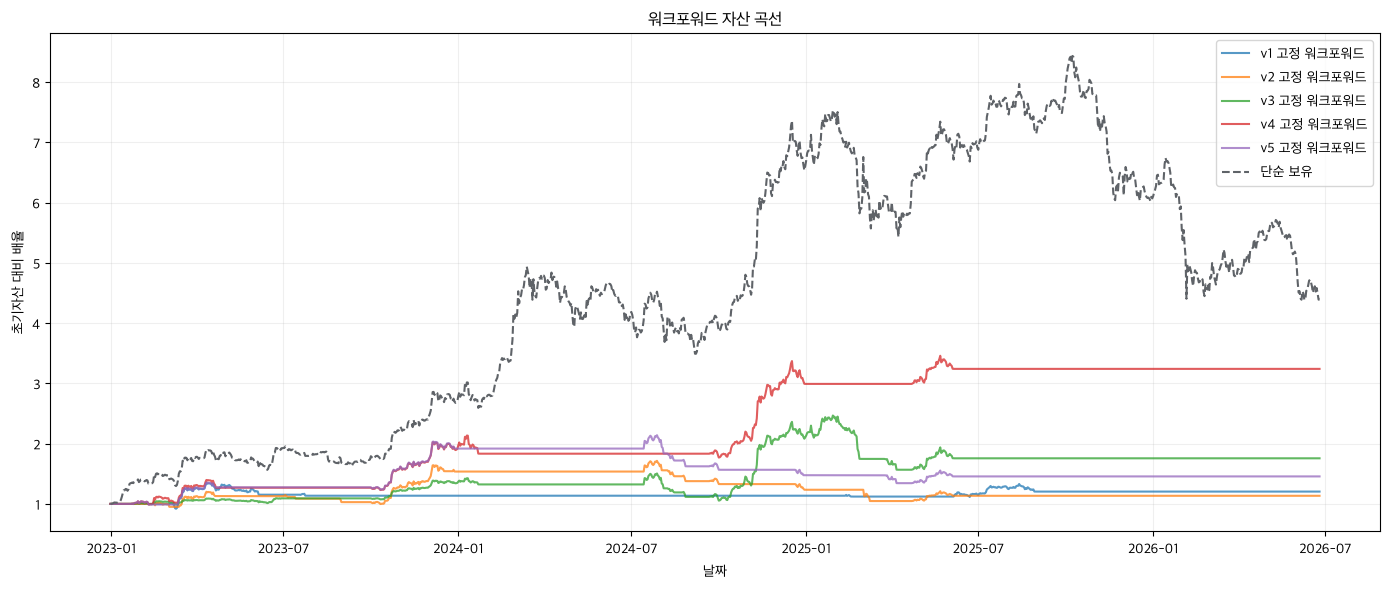

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display

print("추천 범위:", 추천_범위명, "추천 버전:", 추천_버전)

walk_forward_fig = plot_walk_forward_equity(
    결과,
    save_to=PROJECT_ROOT / "outputs" / "backtests" / "latest" / "equity_walk_forward.png",
)
display(walk_forward_fig)
plt.close(walk_forward_fig)


## 6. Java에서 바로 쓰는 계약 파일

`strategy_contracts.json`에는 공통 StrategyInput/StrategyEvaluation 정의, 버전별 정적 검증 결과, 버전 고정 워크포워드 결과, Java가 바로 매핑할 `selectedVersion`과 `javaParamsCamelCase`가 들어간다. Python 모델은 신호와 목표 비중만 계산하고, 수익률 평가와 모델 선택은 공통 평가기/워크포워드 선택기가 담당한다. Java 쪽에서는 추천된 `selectedVersion`으로 v1~v5 엔진을 고르고 `javaParamsCamelCase`를 해당 params 객체에 매핑하면 된다.


In [6]:
출력_경로 = 결과.write_outputs()
순위표.to_csv(출력_경로 / "summary.csv", index=False)
계약 = 결과.contracts()
추천계약 = 계약["walkForwardByVersion"][추천_버전]

print(f"출력 경로: {출력_경로}")
print("\nJava가 바로 사용할 추천 워크포워드 후보")
print("추천 범위:", 추천_범위명)
print("선택 버전:", 추천계약["selectedVersion"])
print("학습 종료:", 추천계약["trainedThrough"])
print("적용 시작:", 추천계약["effectiveFrom"])
pprint(추천계약["javaParamsCamelCase"])

print("\n버전별 정적 선택 파라미터와 마지막 평가 예시")
for 버전, payload in 계약["versions"].items():
    print("-", 버전, "Java 연동:", payload["javaInteropReady"])
    pprint(payload["javaParamsCamelCase"])
    decision = payload["lastEvaluation"]["decision"]
    print("  마지막 평가:", decision["action"], decision["signalReason"], "target=", decision["targetPositionRatio"])


출력 경로: /Users/moon/IdeaProjects/evergreen/outputs/backtests/latest

Java가 바로 사용할 추천 워크포워드 후보
추천 범위: full_3y_train_6m_test
선택 버전: v4
학습 종료: 2026-06-12T00:00:00+00:00
적용 시작: 2026-06-13T00:00:00+00:00
{'atrPeriod': 14,
 'atrTrailMultiplier': 3.0,
 'regimeBand': 0.02,
 'regimeEmaLen': 200,
 'weeklyEmaLen': 10}

버전별 정적 선택 파라미터와 마지막 평가 예시
- v1 Java 연동: True
{'maLen': 110, 'maSlopeDays': 1, 'rsiBuy': 45.0}
  마지막 평가: HOLD SETUP_SELL target= 0.0
- v2 Java 연동: True
{'atrPeriod': 20,
 'atrTrailMultiplier': 2.0,
 'regimeBand': 0.01,
 'regimeEmaLen': 180}
  마지막 평가: HOLD NONE target= 0.0
- v3 Java 연동: True
{'atrPeriod': 14,
 'atrTrailMultiplier': 3.0,
 'maxLeverage': 1.5,
 'minExposure': 0.0,
 'regimeBand': 0.02,
 'regimeEmaLen': 200,
 'volTarget': 0.04}
  마지막 평가: HOLD NONE target= 0.0
- v4 Java 연동: True
{'atrPeriod': 14,
 'atrTrailMultiplier': 3.0,
 'regimeBand': 0.02,
 'regimeEmaLen': 200,
 'weeklyEmaLen': 10}
  마지막 평가: HOLD NONE target= 0.0
- v5 Java 연동: True
{'atrMultHighVol': 5.0,
 'atrMultLowV

## 7. 실제 Upbit 데이터로 실행할 때

공식 SDK를 쓰려면 의존성을 동기화한 뒤 `.venv`의 `Python 3` 커널로 열고 위에서부터 순서대로 실행한다.

```bash
uv sync
uv run jupyter lab backtest_playground.ipynb
uv run jupyter notebook backtest_playground.ipynb
```

최초 실행은 Upbit 일봉 API를 호출하고, 같은 기간/마켓은 다음부터 CSV 캐시를 먼저 읽는다. API 키가 필요한 주문/계좌 기능은 여기서 사용하지 않고, 공개 캔들 데이터만 조회한다.
